### Variance Gamma framework and pricing objective

The Variance Gamma process is used to model log-returns with skewness and excess kurtosis. Under the statistical measure, one increment over a time interval can be written as

$$
X_t^P
=
\mu_P t + \theta G_t + \sigma W_{G_t},
\qquad
G_t \sim \Gamma\!\left(\frac{t}{\nu},\nu\right).
$$

Here `mu_P` controls the statistical drift, `theta` controls asymmetry, `sigma` controls the Brownian volatility inside the subordinated process, and `nu` controls the variance rate of the Gamma subordinator.

For option pricing, the terminal asset value is represented as

$$
S_T = S_0 \exp(X_T^Q),
$$

and the European call price is

$$
V
=
e^{-rT}
\mathbb{E}^Q
\left[
\max(S_T-K,0)
\right].
$$

The risk-neutral drift is chosen so that the discounted asset price is a martingale. For the VG parameterization used here, this drift is

$$
\gamma_0^Q
=
r+
\frac{1}{\nu}
\ln\!\left(
1-\theta\nu-\frac{1}{2}\sigma^2\nu
\right).
$$

The numerical experiment separates three pricing constructions. A model-based Fourier price is computed from the parametric VG characteristic function. A data-driven Fourier price is computed from the empirical characteristic function. A hybrid Monte Carlo estimator samples from a neural approximation of the empirical cumulative distribution function.

The empirical characteristic function for observed log-returns is

$$
\widehat{\varphi}(\xi)
=
\frac{1}{N_{\mathrm{obs}}}
\sum_{j=1}^{N_{\mathrm{obs}}}
\exp(i\xi X_j).
$$

The neural cumulative distribution approximation has the form

$$
\widehat{F}(x)
=
\sum_{j=1}^{N}
p_j
\sigma(\alpha_j x+\beta_j),
\qquad
p_j\ge 0,
\qquad
\sum_{j=1}^{N}p_j=1.
$$

This representation is later used as a mixture model for Monte Carlo sampling.

In [ ]:
seed = 42
calibration_seed = 123

r = 0.05
T = 1 / 2
K = 100
z = -2

mu_P_true = 0.1
true_theta = -0.1
true_sigma = 0.2
true_nu = 0.5

n_obs_calibration = 150000


integer_substeps = 252

dt_calibration = T / integer_substeps
ecf_power_T = T / dt_calibration
tau_integer = int(round(ecf_power_T))
if abs(ecf_power_T - tau_integer) > 1e-12:
    raise ValueError("dt_calibration must divide T exactly for integer-power ECF mode.")
n_steps_pricing = tau_integer

ecf_power_method = "direct_XT_no_power" if tau_integer == 1 else "integer_repeated_multiplication"

ecf_chunk_size = 1024

apply_ecf_tail_cleanup = True
ecf_tail_abs_cutoff = 2.0

use_estimated_vg_params_for_dmc = True

M = 400_000
confidence = 0.95

L = M

N = 16
epochs = 5000

m_ref = 18
d_ref = 0.0001

d5e3 = 0.005
d1e3 = 0.001
d5e4 = 0.0005

m12 = 12
m13 = 13
m14 = 14
m15 = 15
m16 = 16
m17 = 17


### Report logging

The numerical procedure produces printed diagnostics, tables, and timing information. To keep these outputs in a single external report, the standard output stream is duplicated into two destinations:

$$
\mathrm{stdout}
\longmapsto
\left(
\mathrm{console},
\mathrm{report\ file}
\right).
$$

The report filename is determined by the main numerical parameters,

$$
\mathrm{ReportName}
=
f(N_{\mathrm{obs}},\Delta t,q,N,\mathrm{epochs},L),
$$

where `N_obs` is the empirical sample size, `Delta t` is the observation interval, `q` is the integer horizon multiplier, `N` is the number of sigmoid components, `epochs` is the number of training epochs, and `L` is the Monte Carlo sample size.

All later printed quantities are therefore available both in the notebook output and in the saved text report.

In [ ]:
import sys
from datetime import datetime

try:
    from google.colab import files
except Exception:
    class _FilesFallback:
        @staticmethod
        def download(path):
            print(f"[download skipped outside Google Colab] {path}")
    files = _FilesFallback()

REPORT_PATH = (
    f"VG_DIRECT_ECF_Nobs={n_obs_calibration}_dt={dt_calibration:.6f}_"
    f"tau={tau_integer}_Nneurons={N}_EP={epochs}_L={L}.txt"
)

class Tee:
    def __init__(self, *streams):
        self.streams = streams
    def write(self, data):
        for s in self.streams:
            s.write(data)
            s.flush()
    def flush(self):
        for s in self.streams:
            s.flush()

_report_f = open(REPORT_PATH, "w", encoding="utf-8")

_old_stdout = sys.stdout
sys.stdout = Tee(sys.stdout, _report_f)

print("=== Variance Gamma: direct empirical-ChF with integer/no-power horizon handling ===")
print("Generated:", datetime.now().isoformat(timespec="seconds"))
print()


=== Variance Gamma: direct empirical-ChF with integer/no-power horizon handling ===
Generated: 2026-06-07T10:42:13



## 0. Theory and definitions

### Variance Gamma model, observation horizon, and risk-neutral adjustment

The statistical VG model is parameterized by

$$
\mu_P\in\mathbb{R},
\qquad
\theta\in\mathbb{R},
\qquad
\sigma>0,
\qquad
\nu>0.
$$

A synthetic log-return over the observation interval is generated as

$$
X_{\Delta t}
=
\mu_P\Delta t
+
\theta G_{\Delta t}
+
\sigma W_{G_{\Delta t}},
\qquad
G_{\Delta t}
\sim
\Gamma\!\left(\frac{\Delta t}{\nu},\nu\right).
$$

The pricing horizon is denoted by

$$
T.
$$

When the observation interval equals the pricing horizon,

$$
\Delta t=T,
$$

each observed value is a full-horizon log-return:

$$
X_j=X_T.
$$

For direct parametric Monte Carlo pricing, VG parameters are estimated from the sample and the drift is replaced by the risk-neutral drift

$$
\gamma_0
=
r+
\frac{1}{\nu}
\ln\!\left(
1-\theta\nu-\frac{1}{2}\sigma^2\nu
\right).
$$

The risk-neutral full-horizon log-return is then simulated as

$$
X_T^Q
=
\gamma_0T
+
\theta G_T
+
\sigma W_{G_T}.
$$

For empirical Fourier pricing, the characteristic function is estimated directly from the observed sample:

$$
\widehat{\varphi}_{X_{\Delta t}}(\xi_k)
=
\frac{1}{N_{\mathrm{obs}}}
\sum_{j=1}^{N_{\mathrm{obs}}}
\exp(i\xi_kX_j).
$$

The empirical drift adjustment is

$$
\omega
=
r
-
\frac{1}{\Delta t}
\ln\!\left(
\frac{1}{N_{\mathrm{obs}}}
\sum_{j=1}^{N_{\mathrm{obs}}}
\exp(X_j)
\right).
$$

If the horizon consists of an integer number of observation intervals,

$$
T=q\Delta t,
\qquad
q\in\mathbb{N},
$$

then the empirical risk-neutral characteristic function over the pricing horizon is

$$
\widehat{\varphi}_{X_T^Q}(\xi_k)
=
\left(
\widehat{\varphi}_{X_{\Delta t}}(\xi_k)
\right)^q
\exp(i\xi_k\omega T).
$$

For the case

$$
q=1,
$$

the power term is equal to the empirical characteristic function itself.

### Logistic sigmoid and inverse transform

The logistic sigmoid is defined as

$$
\sigma(x)
=
\frac{1}{1+\exp(-x)}.
$$

It maps the real line to the interval

$$
(0,1),
$$

and is smooth, bounded, and strictly increasing. These properties make it suitable for constructing approximations of cumulative distribution functions.

The inverse sigmoid is the logit transform:

$$
\operatorname{logit}(u)
=
\ln\!\left(\frac{u}{1-u}\right),
\qquad
0<u<1.
$$

The two transformations satisfy

$$
\sigma(\operatorname{logit}(u))=u,
\qquad
\operatorname{logit}(\sigma(x))=x.
$$

If

$$
U\sim U(0,1),
$$

then

$$
Y=\operatorname{logit}(U)
$$

has the standard logistic distribution. This inverse-transform relation is used later to sample from sigmoid components in the hybrid Monte Carlo procedure.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import ifft, fftfreq
import cmath
import math
import tensorflow as tf
import time
from scipy.stats import t, skew, kurtosis
from scipy.optimize import least_squares


def sigmoid(x):
    return 1 / (1 + math.exp(-x))


def inverse_logistic(u):
    return np.log(u / (1 - u))

### Analytical VG characteristic function and martingale drift

The parametric VG model is described through its characteristic exponent. For the parameterization used here,

$$
\psi(\xi)
=
-i\gamma_0\xi
+
\frac{1}{\nu}
\ln\!\left(
1-i\theta\nu\xi
+
\frac{1}{2}\sigma^2\nu\xi^2
\right).
$$

The corresponding characteristic function over time `t` is

$$
\varphi_{X_t}(\xi)
=
\exp\!\left(-t\psi(\xi)\right).
$$

The martingale condition for the discounted asset price requires

$$
\mathbb{E}^Q[\exp(X_T^Q)]
=
\exp(rT).
$$

For the VG model, this condition gives the drift

$$
\gamma_0
=
r+
\frac{1}{\nu}
\ln\!\left(
1-\theta\nu-\frac{1}{2}\sigma^2\nu
\right).
$$

The following implementation defines these analytical components for parametric VG simulation and model-based Fourier pricing.

In [ ]:
def compute_gamma0(r, theta, sigma, nu):
    arg = 1.0 - theta * nu - 0.5 * sigma * sigma * nu
    if arg <= 0:
        raise ValueError(
            "Risk-neutral martingale correction is impossible: "
            f"1 - theta*nu - 0.5*sigma^2*nu = {arg:.6e} <= 0"
        )
    gamma0 = r + (1.0 / nu) * np.log(arg)
    return gamma0


def vg_chexp(xi, theta, sigma, nu, gamma0):
    return (
        -1j * gamma0 * xi
        + (1.0 / nu) * np.log(
            1.0 - 1j * theta * nu * xi + 0.5 * sigma * sigma * nu * xi * xi
        )
    )


def vg_chf(xi, t, theta, sigma, nu, gamma0):
    temp1 = vg_chexp(xi, theta, sigma, nu, gamma0)
    return cmath.exp(-t * temp1)

### Synthetic VG sample, moment calibration, and empirical drift adjustment

A synthetic calibration sample consists of observed VG log-returns

$$
X_1,\ldots,X_{N_{\mathrm{obs}}}.
$$

The sample is generated under the statistical measure with parameters

$$
(\mu_P,\theta,\sigma,\nu).
$$

The method-of-moments calibration uses the sample mean, variance, skewness, and excess kurtosis. The estimated drift is obtained from the sample mean after accounting for the theoretical mean contribution of the Gamma-subordinated term.

The empirical characteristic function is computed as the direct sample average

$$
\widehat{\varphi}_{X_{\Delta t}}(\xi)
=
\frac{1}{N_{\mathrm{obs}}}
\sum_{j=1}^{N_{\mathrm{obs}}}
\exp(i\xi X_j).
$$

The empirical risk-neutral adjustment is determined by enforcing the exponential moment condition over the observation interval:

$$
\frac{1}{N_{\mathrm{obs}}}
\sum_{j=1}^{N_{\mathrm{obs}}}
\exp(X_j+\omega\Delta t)
=
\exp(r\Delta t).
$$

Solving this condition gives

$$
\omega
=
r
-
\frac{1}{\Delta t}
\ln\!\left(
\frac{1}{N_{\mathrm{obs}}}
\sum_{j=1}^{N_{\mathrm{obs}}}
\exp(X_j)
\right).
$$

For the full pricing horizon, where

$$
T=q\Delta t,
\qquad
q\in\mathbb{N},
$$

the empirical risk-neutral characteristic function is

$$
\widehat{\varphi}_{X_T^Q}(\xi)
=
\left(
\widehat{\varphi}_{X_{\Delta t}}(\xi)
\right)^q
\exp(i\xi\omega T).
$$

The direct computation has complexity

$$
O(MN_{\mathrm{obs}}),
$$

where `M` is the number of Fourier frequencies.

In [ ]:
def simulate_vg_log_returns(mu_P, theta, sigma, nu, dt, n_obs, seed):
    """Simulate synthetic VG log-returns under the statistical measure P."""
    rng = np.random.default_rng(seed)
    G = rng.gamma(shape=dt / nu, scale=nu, size=n_obs)
    Z = rng.normal(loc=0.0, scale=1.0, size=n_obs)
    log_returns = mu_P * dt + theta * G + sigma * np.sqrt(G) * Z
    prices = 100.0 * np.exp(np.cumsum(log_returns))
    prices = np.insert(prices, 0, 100.0)
    return log_returns, prices


def vg_standardized_moments(theta, sigma, nu, dt):
    """Return variance, skewness and excess kurtosis of one VG increment."""
    A = sigma**2 + theta**2 * nu
    variance = A * dt
    skewness = theta * nu * (3.0 * sigma**2 + 2.0 * theta**2 * nu) / (
        A**1.5 * np.sqrt(dt)
    )
    excess_kurtosis = 3.0 * nu * (
        sigma**4 + 4.0 * sigma**2 * theta**2 * nu + 2.0 * theta**4 * nu**2
    ) / (A**2 * dt)
    return variance, skewness, excess_kurtosis


def estimate_vg_moments(log_returns, dt):
    """
    Estimate VG parameters by matching variance, skewness and excess kurtosis.

    The optimization is performed over (log_sigma, log_nu, theta), so sigma and nu
    are always positive. The drift mu_P is then recovered from the sample mean.
    """
    log_returns = np.asarray(log_returns, dtype=float)

    mean_hat = float(np.mean(log_returns))
    var_hat = float(np.var(log_returns, ddof=1))
    skew_hat = float(skew(log_returns, bias=False))
    kurt_hat = float(kurtosis(log_returns, fisher=True, bias=False))

    if var_hat <= 0:
        raise ValueError("Sample variance must be positive.")
    if kurt_hat <= 0:
        raise ValueError(
            "Sample excess kurtosis must be positive for VG calibration. "
            f"Got {kurt_hat:.6f}."
        )

    sigma0 = max(np.sqrt(var_hat / dt), 1e-6)
    nu0 = max(kurt_hat * dt / 3.0, 1e-6)
    sign = -1.0 if skew_hat < 0 else 1.0

    theta_starts = [0.0, sign * 0.02, sign * 0.05, sign * 0.10, sign * 0.20, -sign * 0.10]
    sigma_scales = [0.5, 1.0, 1.5]
    nu_scales = [0.5, 1.0, 2.0]

    def residuals(params):
        log_sigma, log_nu, theta = params
        sigma = np.exp(log_sigma)
        nu = np.exp(log_nu)
        var_model, skew_model, kurt_model = vg_standardized_moments(theta, sigma, nu, dt)

        return np.array([
            np.log(var_model / var_hat),
            skew_model - skew_hat,
            np.log(kurt_model / kurt_hat),
        ])

    best = None
    for theta0 in theta_starts:
        for s_scale in sigma_scales:
            for n_scale in nu_scales:
                x0 = np.array([
                    np.log(max(sigma0 * s_scale, 1e-8)),
                    np.log(max(nu0 * n_scale, 1e-8)),
                    theta0,
                ])
                result = least_squares(
                    residuals,
                    x0=x0,
                    bounds=([-10.0, -10.0, -5.0], [3.0, 5.0, 5.0]),
                    max_nfev=20_000,
                    xtol=1e-12,
                    ftol=1e-12,
                    gtol=1e-12,
                )
                if best is None or result.cost < best.cost:
                    best = result

    sigma_hat = float(np.exp(best.x[0]))
    nu_hat = float(np.exp(best.x[1]))
    theta_hat = float(best.x[2])
    mu_P_hat = float(mean_hat / dt - theta_hat)

    var_fit, skew_fit, kurt_fit = vg_standardized_moments(theta_hat, sigma_hat, nu_hat, dt)

    return {
        "mu_P": mu_P_hat,
        "theta": theta_hat,
        "sigma": sigma_hat,
        "nu": nu_hat,
        "sample_mean": mean_hat,
        "sample_variance": var_hat,
        "sample_skewness": skew_hat,
        "sample_excess_kurtosis": kurt_hat,
        "fitted_variance": var_fit,
        "fitted_skewness": skew_fit,
        "fitted_excess_kurtosis": kurt_fit,
        "optimization_cost": float(best.cost),
        "optimization_success": bool(best.success),
        "optimization_message": best.message,
    }


def empirical_drift_correction(log_returns_delta, r, dt):
    """Compute omega from the empirical martingale condition for one increment X_dt."""
    mean_exp = float(np.mean(np.exp(log_returns_delta)))
    if mean_exp <= 0:
        raise ValueError("mean(exp(X_delta)) must be positive.")
    return float(r - (1.0 / dt) * np.log(mean_exp))


def empirical_chf_delta_direct(xi_values, log_returns_delta, chunk_size=None):
    """
    Direct empirical characteristic function of one increment X_dt.

    This implements exactly

        phi_hat(xi_k) = (1/N_obs) sum_j exp(i * xi_k * X_j).

    Chunking changes only memory usage; it does not change the formula.
    """
    xi_values = np.asarray(xi_values, dtype=float)
    log_returns_delta = np.asarray(log_returns_delta, dtype=float)

    if chunk_size is None:
        chunk_size = ecf_chunk_size

    out = np.empty(xi_values.shape, dtype=np.complex128)
    for start in range(0, len(xi_values), chunk_size):
        end = min(start + chunk_size, len(xi_values))
        out[start:end] = np.mean(
            np.exp(1j * xi_values[start:end, None] * log_returns_delta[None, :]),
            axis=1,
        )
    return out


def get_integer_ecf_steps(dt, T, tol=1e-12):
    """Return q = T/dt and require it to be integer-valued."""
    tau = float(T / dt)
    q = int(round(tau))
    if abs(tau - q) > tol:
        raise ValueError(
            "The empirical-ChF horizon conversion now requires T/dt to be an integer. "
            f"Got T/dt = {tau:.12f}. Set dt_calibration = T / q."
        )
    if q < 1:
        raise ValueError("T/dt must be at least 1.")
    return q


def chf_power_by_repeated_multiplication(phi_values, n_steps):
    """
    Raise a characteristic function to an integer power by ordinary multiplication.

    This avoids exp(n * Log(phi)) and therefore avoids the branch-choice issue of
    the complex logarithm. For n_steps = 1, the input is returned unchanged.
    """
    n_steps = int(n_steps)
    if n_steps < 1:
        raise ValueError("n_steps must be a positive integer.")

    phi_values = np.asarray(phi_values, dtype=np.complex128)
    if n_steps == 1:
        return phi_values.copy()

    out = np.ones_like(phi_values, dtype=np.complex128)
    for _ in range(n_steps):
        out *= phi_values
    return out


def empirical_chf_T_direct(xi_values, log_returns_delta, omega, dt, T):
    """
    Direct empirical risk-neutral ChF for the pricing horizon X_T.

    We require q = T/dt to be an integer. Then

        phi_Q_XT(xi) = phi_hat_Xdt(xi)^q * exp(i*xi*omega*T),

    where the integer power is computed by repeated multiplication. In the default
    experiment dt = T and q = 1, so no power is applied.
    """
    q = get_integer_ecf_steps(dt, T)
    phi_delta = empirical_chf_delta_direct(xi_values, log_returns_delta)
    phi_delta_power = chf_power_by_repeated_multiplication(phi_delta, q)
    return phi_delta_power * np.exp(1j * np.asarray(xi_values) * omega * T)


def print_parameter_comparison(est):
    rows = [
        ("mu_P", mu_P_true, est["mu_P"]),
        ("theta", true_theta, est["theta"]),
        ("sigma", true_sigma, est["sigma"]),
        ("nu", true_nu, est["nu"]),
    ]

    print("Synthetic VG parameter recovery by method of moments for the DMC baseline")
    print(f"{'parameter':>12}{'true':>16}{'estimated':>16}{'abs error':>16}")
    for name, true_val, est_val in rows:
        print(f"{name:>12}{true_val:>16.8f}{est_val:>16.8f}{abs(est_val - true_val):>16.8f}")
    print()

    print("Moment matching diagnostics for one small increment X_delta")
    print(f"{'moment':>24}{'sample':>18}{'fitted':>18}{'difference':>18}")
    diagnostics = [
        ("variance", est["sample_variance"], est["fitted_variance"]),
        ("skewness", est["sample_skewness"], est["fitted_skewness"]),
        ("excess kurtosis", est["sample_excess_kurtosis"], est["fitted_excess_kurtosis"]),
    ]
    for name, sample_val, fitted_val in diagnostics:
        print(f"{name:>24}{sample_val:>18.8e}{fitted_val:>18.8e}{(fitted_val - sample_val):>18.8e}")
    print()
    print(f"Optimization success: {est['optimization_success']}")
    print(f"Optimization cost:    {est['optimization_cost']:.8e}")
    print(f"Optimizer message:    {est['optimization_message']}")
    print()


log_returns_calibration, synthetic_prices = simulate_vg_log_returns(
    mu_P=mu_P_true,
    theta=true_theta,
    sigma=true_sigma,
    nu=true_nu,
    dt=dt_calibration,
    n_obs=n_obs_calibration,
    seed=calibration_seed,
)

vg_mom_estimate = estimate_vg_moments(log_returns_calibration, dt_calibration)
print_parameter_comparison(vg_mom_estimate)

if use_estimated_vg_params_for_dmc:
    mu_P_dmc = vg_mom_estimate["mu_P"]
    theta_dmc = vg_mom_estimate["theta"]
    sigma_dmc = vg_mom_estimate["sigma"]
    nu_dmc = vg_mom_estimate["nu"]
    dmc_parameter_source = "estimated from synthetic observed returns by method of moments"
else:
    mu_P_dmc = mu_P_true
    theta_dmc = true_theta
    sigma_dmc = true_sigma
    nu_dmc = true_nu
    dmc_parameter_source = "true synthetic parameters"

mu_P = mu_P_dmc
theta = theta_dmc
sigma = sigma_dmc
nu = nu_dmc
experiment_source = dmc_parameter_source

omega_empirical = empirical_drift_correction(log_returns_calibration, r, dt_calibration)
risk_neutral_empirical_returns_delta = log_returns_calibration + omega_empirical * dt_calibration

martingale_delta_lhs = float(np.mean(np.exp(risk_neutral_empirical_returns_delta)))
martingale_delta_rhs = float(np.exp(r * dt_calibration))

q_empirical = get_integer_ecf_steps(dt_calibration, T)
martingale_T_lhs = float(martingale_delta_lhs ** q_empirical)
martingale_T_rhs = float(np.exp(r * T))

print("Direct empirical characteristic function branch for FFT/HMC")
print("  one observed return is X_T" if tau_integer == 1 else "  one observed return is X_delta with integer T/dt")
print(f"  N_obs in empirical ChF = {len(log_returns_calibration)}")
print(f"  dt_calibration = {dt_calibration:.10f}")
print(f"  T = {T:.10f}")
print(f"  tau = T / dt = {ecf_power_T:.10f}")
print(f"  integer q = {q_empirical}")
print(f"  ECF power method = {ecf_power_method}")
print(f"  omega_empirical = {omega_empirical:.8f}")
print(f"  mean(exp(X_dt^Q)) = {martingale_delta_lhs:.12f}")
print(f"  exp(r*dt)            = {martingale_delta_rhs:.12f}")
print(f"  delta absolute error = {abs(martingale_delta_lhs - martingale_delta_rhs):.4e}")
print(f"  E[exp(X_T^Q)] from integer product = {martingale_T_lhs:.12f}")
print(f"  exp(r*T)              = {martingale_T_rhs:.12f}")
print(f"  T absolute error      = {abs(martingale_T_lhs - martingale_T_rhs):.4e}")
print()

gamma0_model_ref = compute_gamma0(r, true_theta, true_sigma, true_nu)
constraint_model_ref = 1.0 - true_theta * true_nu - 0.5 * true_sigma**2 * true_nu
martingale_model_ref_lhs = np.exp(gamma0_model_ref * T) * constraint_model_ref ** (-T / true_nu)
martingale_model_ref_rhs = np.exp(r * T)

print("Model FFT reference branch")
print("  source = true synthetic VG model, not empirical ChF")
print(f"  theta_ref  = {true_theta:.8f}")
print(f"  sigma_ref  = {true_sigma:.8f}")
print(f"  nu_ref     = {true_nu:.8f}")
print(f"  gamma0_ref = {gamma0_model_ref:.8f}  # fixed EMM drift")
print(f"  martingale lhs over T = {martingale_model_ref_lhs:.12f}")
print(f"  martingale rhs over T = {martingale_model_ref_rhs:.12f}")
print(f"  absolute error        = {abs(martingale_model_ref_lhs - martingale_model_ref_rhs):.4e}")
print()

xi_diag = np.array([0.0, 1.0, 5.0, 10.0])
phi_delta_diag = empirical_chf_delta_direct(xi_diag, log_returns_calibration)
phi_T_diag = empirical_chf_T_direct(xi_diag, log_returns_calibration, omega_empirical, dt_calibration, T)

print("Diagnostic values of the direct empirical characteristic functions")
print("Observed-step empirical ChF: phi_hat_{X_dt}(xi); here X_dt = X_T when q=1")
print(f"{'xi':>8}{'Re(phi_dt)':>18}{'Im(phi_dt)':>18}{'abs(phi_dt)':>18}")
for xi, val in zip(xi_diag, phi_delta_diag):
    print(f"{xi:>8.2f}{val.real:>18.10f}{val.imag:>18.10f}{abs(val):>18.10f}")
print()
print("Pricing-horizon risk-neutral ChF: phi^Q_{X_T}(xi), using no power for q=1 or integer repeated multiplication for q>1")
print(f"{'xi':>8}{'Re(phi_T)':>18}{'Im(phi_T)':>18}{'abs(phi_T)':>18}")
for xi, val in zip(xi_diag, phi_T_diag):
    print(f"{xi:>8.2f}{val.real:>18.10f}{val.imag:>18.10f}{abs(val):>18.10f}")
print()

gamma0_dmc = compute_gamma0(r, theta_dmc, sigma_dmc, nu_dmc)
constraint_dmc = 1.0 - theta_dmc * nu_dmc - 0.5 * sigma_dmc**2 * nu_dmc
martingale_dmc_lhs = np.exp(gamma0_dmc * T) * constraint_dmc ** (-T / nu_dmc)
martingale_dmc_rhs = np.exp(r * T)

print("DMC parametric VG branch")
print(f"  parameter source = {dmc_parameter_source}")
print(f"  mu_P   = {mu_P_dmc:.8f}  # statistical drift; not used under Q")
print(f"  theta  = {theta_dmc:.8f}")
print(f"  sigma  = {sigma_dmc:.8f}")
print(f"  nu     = {nu_dmc:.8f}")
print(f"  gamma0 = {gamma0_dmc:.8f}")
print(f"  martingale lhs over T = {martingale_dmc_lhs:.12f}")
print(f"  martingale rhs over T = {martingale_dmc_rhs:.12f}")
print(f"  absolute error        = {abs(martingale_dmc_lhs - martingale_dmc_rhs):.4e}")
print()

_EMPIRICAL_GRID_CACHE = {}


### Empirical Fourier construction of the cumulative distribution function

For a Fourier grid with

$$
M=2^m
$$

and spatial step `d`, the spatial grid is

$$
x_k
=
-\frac{Md}{2}+kd,
\qquad
k=0,\ldots,M-1.
$$

The corresponding frequency grid is

$$
\xi_l
=
\frac{\pi}{d}
-
\frac{2\pi l}{dM},
\qquad
l=0,\ldots,M-1.
$$

At each frequency, the empirical characteristic function is evaluated by

$$
\widehat{\varphi}_{X_{\Delta t}}(\xi_l)
=
\frac{1}{N_{\mathrm{obs}}}
\sum_{j=1}^{N_{\mathrm{obs}}}
\exp(i\xi_lX_j).
$$

The pricing-horizon empirical characteristic function is

$$
\widehat{\varphi}_{X_T^Q}(\xi_l)
=
\left(
\widehat{\varphi}_{X_{\Delta t}}(\xi_l)
\right)^q
\exp(i\xi_l\omega T),
\qquad
q=\frac{T}{\Delta t}\in\mathbb{N}.
$$

The inverse Fourier transform recovers a discrete density on the grid. The density is normalized into probabilities,

$$
p_k \ge 0,
\qquad
\sum_{k=0}^{M-1}p_k=1,
$$

and the cumulative distribution function is obtained by

$$
F(x_k)
=
\sum_{j=0}^{k}p_j.
$$

In [ ]:
def _article_grid(m: int, d: float):
    """Return the article's x-grid and frequency grid."""
    M_grid = int(2 ** m)
    k = np.arange(M_grid)
    x = -M_grid * d / 2.0 + k * d
    xi = np.pi / d - (2.0 * np.pi * k) / (d * M_grid)
    return x, xi


def _density_from_characteristic_function_article(phi_values, d: float):
    """
    Article's inverse-FFT density formula:

        p(x_k) = (-1)^k / d * iDFT[phi(xi_l) * (-1)^l](k).

    Numpy's np.fft.ifft is the iDFT with normalization 1/M.
    """
    M_grid = len(phi_values)
    idx = np.arange(M_grid)
    signs = np.where(idx % 2 == 0, 1.0, -1.0)
    density_complex = (signs / d) * np.fft.ifft(phi_values * signs)
    density = density_complex.real
    max_imag_residual = float(np.max(np.abs(density_complex.imag)))
    return density, max_imag_residual


def _postprocess_density_to_cdf(x, density, d, m, tail_abs_cutoff=None):
    """
    Convert an inverted density to probabilities and CDF.

    Finite-sample direct ECF inversion can create tiny oscillatory artifacts in
    extreme tails. This matters for option pricing because exp(x) magnifies tiny
    right-tail artifacts. The optional cutoff removes only the far-tail numerical
    artifacts after the article-style ECF and inverse FFT have already been done.
    """
    density = np.asarray(density, dtype=float).copy()
    raw_integral = float(np.sum(density) * d)
    raw_negative_mass = float(-np.sum(density[density < 0.0]) * d)

    if tail_abs_cutoff is not None:
        density[np.abs(x) > tail_abs_cutoff] = 0.0

    negative_mass_after_cutoff = float(-np.sum(density[density < 0.0]) * d)
    density = np.maximum(density, 0.0)

    positive_integral = float(np.sum(density) * d)
    if positive_integral <= 0:
        raise ValueError(
            f"Non-positive density integral after postprocessing for m={m}, d={d}."
        )

    density = density / positive_integral
    probabilities = density * d
    cdf = np.cumsum(probabilities)
    cdf = np.clip(cdf, 0.0, 1.0)
    cdf[-1] = 1.0

    mean_exp_grid = float(np.sum(np.exp(x) * probabilities))

    return {
        "density": density,
        "probabilities": probabilities,
        "cdf": cdf,
        "raw_integral": raw_integral,
        "raw_negative_mass": raw_negative_mass,
        "negative_mass_after_cutoff": negative_mass_after_cutoff,
        "positive_integral_before_normalization": positive_integral,
        "mean_exp_grid_after_postprocessing": mean_exp_grid,
    }


def _empirical_grid(m: int, d: float):
    """
    Return grid, probabilities, density and CDF of X_T^Q built from observed data.

    This function follows the direct empirical-ChF idea:

        1. build the article frequency grid xi_l;
        2. compute phi_hat_Xdt(xi_l) = mean_j exp(i xi_l X_j) directly;
        3. compute phi_Q_XT(xi_l) = phi_hat_Xdt(xi_l)^q * exp(i xi_l omega T),
           where q = T/dt is integer;
        4. invert by the article's inverse-FFT formula;
        5. integrate the density to obtain the CDF.

    In the default experiment dt = T, q = 1, so no power is applied.
    """
    q_empirical = get_integer_ecf_steps(dt_calibration, T)
    key = (int(m), float(d), len(log_returns_calibration), q_empirical, float(omega_empirical), ecf_power_method)
    if key in _EMPIRICAL_GRID_CACHE:
        return _EMPIRICAL_GRID_CACHE[key]

    x, xi = _article_grid(m, d)

    print(f"Computing direct empirical ChF on FFT grid: m={m}, d={d}, M={len(x)}, N_obs={len(log_returns_calibration)}")
    start_time = time.perf_counter()
    phi_delta = empirical_chf_delta_direct(
        xi,
        log_returns_calibration,
        chunk_size=ecf_chunk_size,
    )
    ecf_time = time.perf_counter() - start_time

    phi_delta_power = chf_power_by_repeated_multiplication(phi_delta, q_empirical)
    phi_T_Q = phi_delta_power * np.exp(1j * xi * omega_empirical * T)

    density_raw, max_imag_residual = _density_from_characteristic_function_article(phi_T_Q, d)

    tail_cutoff = ecf_tail_abs_cutoff if apply_ecf_tail_cleanup else None
    processed = _postprocess_density_to_cdf(
        x=x,
        density=density_raw,
        d=d,
        m=m,
        tail_abs_cutoff=tail_cutoff,
    )

    target_mean_exp = float(np.exp(r * T))
    print(f"  direct ECF time = {ecf_time:.4f} sec")
    print(f"  tau = T/dt = {ecf_power_T:.10f} (integer q = {q_empirical})")
    print(f"  ECF power method = {ecf_power_method}")
    print(f"  raw density integral = {processed['raw_integral']:.12f}")
    print(f"  raw negative mass = {processed['raw_negative_mass']:.4e}")
    print(f"  tail cutoff applied = {tail_cutoff}")
    print(f"  positive integral before normalization = {processed['positive_integral_before_normalization']:.12f}")
    print(f"  max imaginary residual after iFFT = {max_imag_residual:.4e}")
    print(f"  grid E[exp(X_T^Q)] after postprocessing = {processed['mean_exp_grid_after_postprocessing']:.12f}")
    print(f"  target exp(rT) = {target_mean_exp:.12f}")
    print(f"  absolute martingale grid error = {abs(processed['mean_exp_grid_after_postprocessing'] - target_mean_exp):.4e}")
    print()

    _EMPIRICAL_GRID_CACHE[key] = {
        "x": x,
        "xi": xi,
        "phi_delta": phi_delta,
        "phi_T_Q": phi_T_Q,
        "probabilities": processed["probabilities"],
        "density": processed["density"],
        "cdf": processed["cdf"],
        "mass_inside": float(np.sum(processed["probabilities"])),
        "raw_integral": processed["raw_integral"],
        "raw_negative_mass": processed["raw_negative_mass"],
        "negative_mass_after_cutoff": processed["negative_mass_after_cutoff"],
        "positive_integral_before_normalization": processed["positive_integral_before_normalization"],
        "max_imag_residual_after_ifft": max_imag_residual,
        "mean_exp_grid_after_postprocessing": processed["mean_exp_grid_after_postprocessing"],
        "ecf_time": ecf_time,
        "x_min": float(x[0]),
        "x_max": float(x[-1]),
    }
    return _EMPIRICAL_GRID_CACHE[key]


_MODEL_REFERENCE_GRID_CACHE = {}


def vg_chexp_vectorized(xi, theta, sigma, nu, gamma0):
    """Vectorized VG characteristic exponent for FFT grids."""
    xi = np.asarray(xi, dtype=np.complex128)
    return (
        -1j * gamma0 * xi
        + (1.0 / nu) * np.log(
            1.0 - 1j * theta * nu * xi + 0.5 * sigma * sigma * nu * xi * xi
        )
    )


def _model_reference_grid(m: int, d: float):
    """
    Return the model FFT reference grid for X_T^Q.

    This is the non-empirical benchmark requested by the supervisor:
    the true synthetic VG parameters are used, and only the drift is replaced by
    the fixed mean-correction EMM drift gamma0_model_ref.
    """
    key = (int(m), float(d), float(T), float(r), float(true_theta), float(true_sigma), float(true_nu), float(gamma0_model_ref))
    if key in _MODEL_REFERENCE_GRID_CACHE:
        return _MODEL_REFERENCE_GRID_CACHE[key]

    x, xi = _article_grid(m, d)
    phi_T_Q_model = np.exp(
        -T * vg_chexp_vectorized(
            xi,
            theta=true_theta,
            sigma=true_sigma,
            nu=true_nu,
            gamma0=gamma0_model_ref,
        )
    )

    density_raw, max_imag_residual = _density_from_characteristic_function_article(phi_T_Q_model, d)
    processed = _postprocess_density_to_cdf(
        x=x,
        density=density_raw,
        d=d,
        m=m,
        tail_abs_cutoff=None,
    )

    target_mean_exp = float(np.exp(r * T))
    print(f"Computing MODEL FFT reference grid: m={m}, d={d}, M={len(x)}")
    print(f"  gamma0_model_ref = {gamma0_model_ref:.10f}")
    print(f"  raw density integral = {processed['raw_integral']:.12f}")
    print(f"  raw negative mass = {processed['raw_negative_mass']:.4e}")
    print(f"  positive integral before normalization = {processed['positive_integral_before_normalization']:.12f}")
    print(f"  max imaginary residual after iFFT = {max_imag_residual:.4e}")
    print(f"  grid E[exp(X_T^Q)] after postprocessing = {processed['mean_exp_grid_after_postprocessing']:.12f}")
    print(f"  target exp(rT) = {target_mean_exp:.12f}")
    print(f"  absolute martingale grid error = {abs(processed['mean_exp_grid_after_postprocessing'] - target_mean_exp):.4e}")
    print()

    _MODEL_REFERENCE_GRID_CACHE[key] = {
        "x": x,
        "xi": xi,
        "phi_T_Q_model": phi_T_Q_model,
        "probabilities": processed["probabilities"],
        "density": processed["density"],
        "cdf": processed["cdf"],
        "mass_inside": float(np.sum(processed["probabilities"])),
        "raw_integral": processed["raw_integral"],
        "raw_negative_mass": processed["raw_negative_mass"],
        "negative_mass_after_cutoff": processed["negative_mass_after_cutoff"],
        "positive_integral_before_normalization": processed["positive_integral_before_normalization"],
        "max_imag_residual_after_ifft": max_imag_residual,
        "mean_exp_grid_after_postprocessing": processed["mean_exp_grid_after_postprocessing"],
        "x_min": float(x[0]),
        "x_max": float(x[-1]),
    }
    return _MODEL_REFERENCE_GRID_CACHE[key]


def compute_cdf_empirical(m: int, d: float, r: float,
                          theta: float, sigma: float, nu: float, T: float):
    """
    Construct the empirical-ChF CDF used to train the HMC sampler.

    The arguments (r, theta, sigma, nu, T) are kept only for compatibility with
    the old notebook interface. The empirical-ChF branch does not use analytical
    VG parameters here.
    """
    grid = _empirical_grid(m, d)
    return grid["cdf"].copy(), grid["x"].copy()


def compute_cdf_model_reference(m: int, d: float):
    """Construct the non-empirical model FFT reference CDF."""
    grid = _model_reference_grid(m, d)
    return grid["cdf"].copy(), grid["x"].copy()


def compute_cdf(m: int, d: float, r: float,
                theta: float, sigma: float, nu: float, T: float):
    return compute_cdf_empirical(m, d, r, theta, sigma, nu, T)


### Empirical characteristic-function diagnostic

The finite-sample empirical characteristic function is compared with the analytical VG characteristic function on a diagnostic frequency interval.

For the observed increment, the pointwise error is

$$
e_{\Delta t}(\xi)
=
\left|
\widehat{\varphi}_{X_{\Delta t}}(\xi)
-
\varphi_{X_{\Delta t}}(\xi)
\right|.
$$

For the risk-neutral pricing horizon, the pointwise error is

$$
e_T^Q(\xi)
=
\left|
\widehat{\varphi}_{X_T^Q}(\xi)
-
\varphi_{X_T^Q}(\xi)
\right|.
$$

The diagnostic reports the maximum error,

$$
\max_{\xi} e(\xi),
$$

the root mean squared error,

$$
\sqrt{
\frac{1}{n_\xi}
\sum_{\ell=1}^{n_\xi}
e(\xi_\ell)^2
},
$$

and the mean absolute error,

$$
\frac{1}{n_\xi}
\sum_{\ell=1}^{n_\xi}
e(\xi_\ell).
$$

These quantities measure how closely the empirical characteristic function approximates the parametric characteristic function on the selected frequency grid.

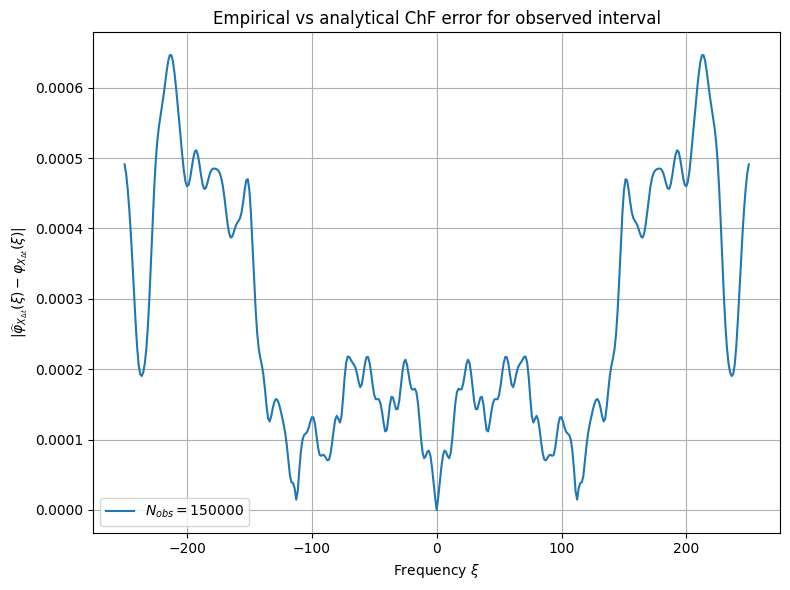

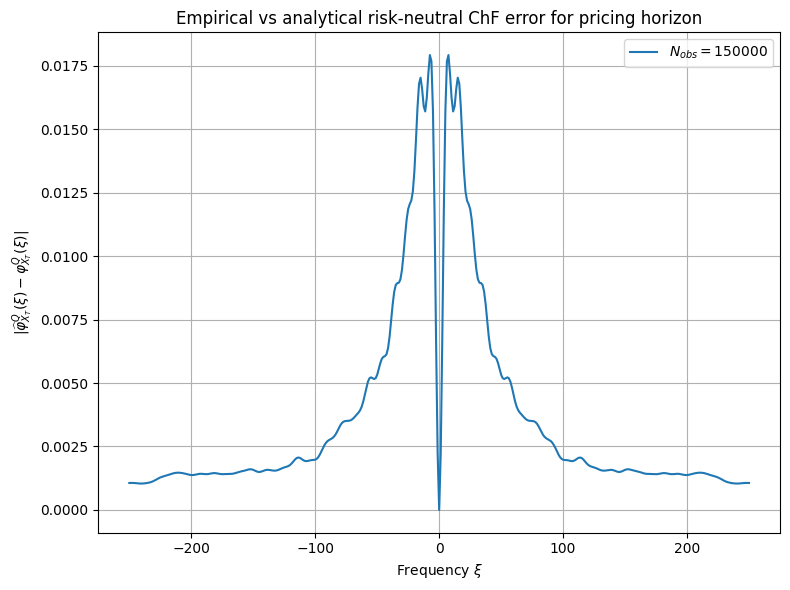

In [ ]:

diagnostic_n_obs_values = [n_obs_calibration]

chf_error_xi_max = 250.0
chf_error_n_xi = 401
chf_error_xi = np.linspace(-chf_error_xi_max, chf_error_xi_max, chf_error_n_xi)

chf_error_freq_chunk_size = 2048

phi_delta_analytical = np.exp(
    -dt_calibration * vg_chexp_vectorized(
        chf_error_xi,
        theta=true_theta,
        sigma=true_sigma,
        nu=true_nu,
        gamma0=mu_P_true,
    )
)

phi_T_Q_analytical = np.exp(
    -T * vg_chexp_vectorized(
        chf_error_xi,
        theta=true_theta,
        sigma=true_sigma,
        nu=true_nu,
        gamma0=gamma0_model_ref,
    )
)

chf_error_curves = {}

print("Empirical ChF error against analytical VG ChF")
print(f"Frequency interval: [-{chf_error_xi_max}, {chf_error_xi_max}]")
print(f"{'N_obs':>12}{'max |err X_dt|':>20}{'RMSE X_dt':>18}{'mean |err X_dt|':>20}"
      f"{'max |err X_T^Q|':>22}{'RMSE X_T^Q':>18}{'mean |err X_T^Q|':>22}{'omega':>16}")

for n_obs_diag in diagnostic_n_obs_values:
    if n_obs_diag > len(log_returns_calibration):
        raise ValueError(
            f"Requested n_obs_diag={n_obs_diag}, but only {len(log_returns_calibration)} "
            "calibration observations are available."
        )

    returns_diag = log_returns_calibration[:n_obs_diag]

    phi_delta_empirical = empirical_chf_delta_direct(
        chf_error_xi,
        returns_diag,
        chunk_size=chf_error_freq_chunk_size,
    )

    omega_diag = empirical_drift_correction(returns_diag, r, dt_calibration)

    q_diag = get_integer_ecf_steps(dt_calibration, T)
    phi_T_Q_empirical = (
        chf_power_by_repeated_multiplication(phi_delta_empirical, q_diag)
        * np.exp(1j * chf_error_xi * omega_diag * T)
    )

    delta_abs_error = np.abs(phi_delta_empirical - phi_delta_analytical)
    T_Q_abs_error = np.abs(phi_T_Q_empirical - phi_T_Q_analytical)

    chf_error_curves[n_obs_diag] = {
        "delta_abs_error": delta_abs_error,
        "T_Q_abs_error": T_Q_abs_error,
    }

    print(
        f"{n_obs_diag:>12}"
        f"{np.max(delta_abs_error):>20.8e}"
        f"{np.sqrt(np.mean(delta_abs_error ** 2)):>18.8e}"
        f"{np.mean(delta_abs_error):>20.8e}"
        f"{np.max(T_Q_abs_error):>22.8e}"
        f"{np.sqrt(np.mean(T_Q_abs_error ** 2)):>18.8e}"
        f"{np.mean(T_Q_abs_error):>22.8e}"
        f"{omega_diag:>16.8f}"
    )

plt.figure(figsize=(8, 6))
for n_obs_diag in diagnostic_n_obs_values:
    plt.plot(
        chf_error_xi,
        chf_error_curves[n_obs_diag]["delta_abs_error"],
        label=rf"$N_{{obs}}={n_obs_diag}$",
    )

plt.title("Empirical vs analytical ChF error for observed interval")
plt.xlabel(r"Frequency $\xi$")
plt.ylabel(r"$|\widehat{\varphi}_{X_{\Delta t}}(\xi)-\varphi_{X_{\Delta t}}(\xi)|$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
for n_obs_diag in diagnostic_n_obs_values:
    plt.plot(
        chf_error_xi,
        chf_error_curves[n_obs_diag]["T_Q_abs_error"],
        label=rf"$N_{{obs}}={n_obs_diag}$",
    )

plt.title("Empirical vs analytical risk-neutral ChF error for pricing horizon")
plt.xlabel(r"Frequency $\xi$")
plt.ylabel(r"$|\widehat{\varphi}^{Q}_{X_T}(\xi)-\varphi^{Q}_{X_T}(\xi)|$")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


### Neural approximation of the empirical cumulative distribution function

The empirical Fourier inversion produces training pairs

$$
(x_i,F(x_i)),
\qquad
i=1,\ldots,n.
$$

The cumulative distribution function is approximated by a one-hidden-layer neural model

$$
\widehat{F}(x)
=
\sum_{j=1}^{N}
p_j
\sigma(\alpha_jx+\beta_j).
$$

where

$$
\sigma(u)
=
\frac{1}{1+\exp(-u)}.
$$

The output weights are constrained as

$$
p_j\ge 0,
\qquad
\sum_{j=1}^{N}p_j=1.
$$

Therefore the approximation is a convex combination of sigmoid functions. The first-layer weights are constrained by

$$
\alpha_j\ge 1.
$$

This lower bound stabilizes the inverse transform used in Monte Carlo sampling. If

$$
U\sim U(0,1),
$$

then

$$
Y=\ln\!\left(\frac{U}{1-U}\right)
$$

has the logistic distribution. For the `j`-th component, the corresponding simulated log-return value is

$$
Z
=
\frac{Y-\beta_j}{\alpha_j}.
$$

Small values of `alpha_j` would enlarge the magnitude of `Z`. Since asset prices are generated as

$$
S_T=S_0\exp(Z),
$$

the lower bound on `alpha_j` reduces numerical instability in simulated payoffs.

The model is trained by minimizing the mean squared error

$$
\mathrm{MSE}
=
\frac{1}{n}
\sum_{i=1}^{n}
\left(
\widehat{F}(x_i)-F(x_i)
\right)^2.
$$

After training, the parameters

$$
\alpha_j,
\qquad
\beta_j,
\qquad
p_j
$$

define the neural representation used by the hybrid Monte Carlo estimator.

In [ ]:
def compute_approximation(x_train, y_train, epochs, batch_size, N, m, d,
                          m_ref, d_ref,
                          r, theta, sigma, nu, T,
                          seed):
    print(len(x_train))

    tag = CURRENT_MODEL_TAG if CURRENT_MODEL_TAG else f"m={m}, d={d}, batch_size={batch_size}"

    tf.keras.utils.set_random_seed(seed)
    np.random.seed(seed)

    class GreaterEqualOne(tf.keras.constraints.Constraint):
        def __call__(self, w):
            return tf.maximum(w, 1.0)

    class EpochLogger(tf.keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            if logs is None:
                return
            if (epoch + 1) % 500 == 0 or epoch == 0:
                print(f"Epoch {epoch + 1}: loss = {logs['loss']}")

    class SumToOne(tf.keras.constraints.Constraint):
        def __init__(self, axis=0):
            self.axis = axis

        def __call__(self, w):
            w = tf.nn.relu(w)
            return w / (tf.reduce_sum(w, axis=self.axis, keepdims=True) + tf.keras.backend.epsilon())

    model = tf.keras.Sequential([
        tf.keras.layers.Dense(
            N,
            input_shape=(1,),
            activation='sigmoid',
            kernel_constraint=GreaterEqualOne(),
            use_bias=True
        ),
        tf.keras.layers.Dense(
            1,
            activation='linear',
            kernel_constraint=SumToOne(),
            use_bias=False
        )
    ])


    optimizer = tf.keras.optimizers.Adam(learning_rate=0.005)
    model.compile(optimizer=optimizer, loss='mse', jit_compile=True)

    start_time = time.perf_counter()
    history = model.fit(
        x_train,
        y_train,
        batch_size=batch_size,
        epochs=epochs,
        verbose=0,
        callbacks=[EpochLogger()]
    )
    end_time = time.perf_counter()

    losses = history.history.get("loss", [])
    if len(losses) > 0:
        print(f"batch_size = {batch_size}, epochs = {epochs}, N = {N}")
        print(f"loss min   = {min(losses):.12e}")
    print(f"train_time = {end_time - start_time:.6f} sec")
    print()

    cdf_ref, x_ref = compute_cdf(m_ref, d_ref, r, theta, sigma, nu, T)

    x_test = x_ref.reshape(-1, 1)
    y_pred = model.predict(x_test, verbose=0)

    plt.figure(figsize=(8, 6))
    plt.plot(x_ref, cdf_ref, label='Fine-grid empirical-ChF CDF', color='blue')
    plt.plot(x_test, y_pred, label='Approximation curve', color='red')
    plt.xlim(-2, 2)

    plt.title('Cumulative Distribution Function')
    plt.xlabel('x')
    plt.ylabel('CDF')
    plt.legend()
    plt.grid(True)

    textstr = (
        rf"$m = {m}$" "\n"
        rf"$d = {d}$" "\n"
        rf"$N = {N}$" "\n"
        rf"$T_{{train}} = {end_time - start_time:.4f}\,\mathrm{{s}}$"
    )

    plt.text(
        0.02, 0.98, textstr,
        transform=plt.gca().transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    filename = f"approximated_cdf_{m}_{d}.pdf"
    plt.savefig(filename, format="pdf", bbox_inches="tight", dpi=500)
    files.download(filename)
    plt.show()

    weights, biases = model.layers[0].get_weights()
    alphas = weights.T.flatten().tolist()
    betas = biases.tolist()

    print("First layer weights (alphas):")
    for a in alphas:
        print(a)
    print()

    print("First layer biases (betas):")
    for b in betas:
        print(b)
    print()

    weights2 = model.layers[1].get_weights()[0]
    probabilities = weights2.T.flatten().tolist()

    print("Second layer weights (probabilities):")
    for pp in probabilities:
        print(pp)
    print()

    train_time = end_time - start_time
    return alphas, betas, probabilities, train_time, model

### Error analysis of the neural CDF approximation

The neural approximation and the fine-grid empirical CDF can be defined on different spatial grids. The comparison is therefore restricted to the common interval

$$
[x_{\min},x_{\max}],
$$

where

$$
x_{\min}
=
\max\!\left(
\min x_{\mathrm{ref}},
\min x_{\mathrm{train}}
\right),
$$

and

$$
x_{\max}
=
\min\!\left(
\max x_{\mathrm{ref}},
\max x_{\mathrm{train}}
\right).
$$

On the retained grid points, the pointwise signed error is

$$
e(x_i)
=
\widehat{F}(x_i)
-
F_{\mathrm{ref}}(x_i).
$$

The absolute error is

$$
|e(x_i)|
=
\left|
\widehat{F}(x_i)
-
F_{\mathrm{ref}}(x_i)
\right|.
$$

The reported maximal deviation is

$$
\max_i |e(x_i)|.
$$

The corresponding signed value indicates whether the neural approximation is above or below the reference CDF at the point of maximal absolute error. The error curve is plotted over the common grid to show the distribution of approximation errors across the state space.

In [ ]:
def compute_cdf_error(x_train, model, ref_x, ref_cdf, m, d, N):

    xmin = max(ref_x.min(), x_train.min())
    xmax = min(ref_x.max(), x_train.max())

    mask = (ref_x >= xmin) & (ref_x <= xmax)
    err_x = ref_x[mask].reshape(-1, 1)
    ref_eval = ref_cdf[mask]

    nn_eval = model.predict(err_x, verbose=0).reshape(-1)

    signed_error = nn_eval - ref_eval
    abs_error = np.abs(signed_error)

    idx = int(np.argmax(abs_error))
    max_abs_err = float(abs_error[idx])
    signed_at_max = float(signed_error[idx])

    print("max |CDF_NN(x) - CDF_ref(x)| =", max_abs_err)
    print("signed error at max abs error =", signed_at_max)
    print("at x =", float(err_x[idx]))

    plt.figure(figsize=(8, 6))
    plt.plot(err_x, signed_error, label='Signed error curve', color='red')
    plt.xlim(-2, 2)

    plt.title('CDF Error')
    plt.xlabel('x')
    plt.ylabel('CDF_NN(x) - CDF_ref(x)')
    plt.legend()
    plt.grid(True)

    textstr = (
        rf"$m = {m}$" "\n"
        rf"$d = {d}$" "\n"
        rf"$N_{{neurons}} = {N}$" "\n"
        rf"$\max |error| = {max_abs_err:.6g}$"
    )

    plt.text(
        0.02, 0.98, textstr,
        transform=plt.gca().transAxes,
        fontsize=11,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8)
    )

    filename = f"cdf_error_{m}_{d}.pdf"
    plt.savefig(
        filename,
        format="pdf",
        bbox_inches="tight",
        dpi=300
    )
    files.download(filename)
    plt.show()

    return signed_error, err_x


### Fourier option pricing from discrete probability grids

Once a risk-neutral probability grid

$$
\{(x_j,p_j)\}_{j=0}^{M-1}
$$

has been recovered, the European call payoff is evaluated at the grid points as

$$
\Pi_j
=
\max(S_0\exp(x_j)-K,0).
$$

The discrete Fourier-based price is then

$$
V_{\mathrm{FFT}}
\approx
e^{-rT}
\sum_{j=0}^{M-1}
\Pi_jp_j.
$$

The same pricing formula can be applied to different probability grids. A model-based grid gives a parametric reference price, while an empirical grid gives a data-driven Fourier price. The following functions implement both cases by integrating the discounted payoff against the corresponding recovered probability distribution.

In [ ]:
def compute_price_fft_empirical(m: int, d: float, S: float,
                                r: float, theta: float, sigma: float, nu: float,
                                T: float, K: float, z: float) -> float:
    """
    Empirical-ChF/FFT price from the recovered risk-neutral empirical distribution.

    Parameters theta, sigma, nu and z are kept for backward compatibility but are
    not used in this empirical version.
    """
    grid = _empirical_grid(m, d)
    x = grid["x"]
    probabilities = grid["probabilities"]

    payoff = np.maximum(S * np.exp(x) - K, 0.0)
    price = np.exp(-r * T) * float(np.sum(payoff * probabilities))
    return price


def compute_price_fft_model_reference(m: int, d: float, S: float,
                                      r: float, T: float, K: float) -> float:
    """
    Non-empirical model FFT reference price.

    This uses the true VG model that generated the data, with the fixed EMM drift
    gamma0_model_ref. It is the benchmark/reference for the final tables.
    """
    grid = _model_reference_grid(m, d)
    x = grid["x"]
    probabilities = grid["probabilities"]

    payoff = np.maximum(S * np.exp(x) - K, 0.0)
    price = np.exp(-r * T) * float(np.sum(payoff * probabilities))
    return price


def compute_price_fft(m: int, d: float, S: float,
                      r: float, theta: float, sigma: float, nu: float,
                      T: float, K: float, z: float) -> float:
    return compute_price_fft_empirical(m, d, S, r, theta, sigma, nu, T, K, z)


### Direct Monte Carlo pricing under moment-estimated VG parameters

The direct Monte Carlo estimator uses a parametric VG model calibrated by the method of moments. With estimated parameters

$$
(\theta,\sigma,\nu),
$$

the risk-neutral drift is

$$
\gamma_0
=
r+
\frac{1}{\nu}
\ln\!\left(
1-\theta\nu-\frac{1}{2}\sigma^2\nu
\right).
$$

A Monte Carlo path for the full pricing horizon is generated as

$$
X_T^Q
=
\gamma_0T
+
\theta G_T
+
\sigma W_{G_T},
\qquad
G_T\sim\Gamma\!\left(\frac{T}{\nu},\nu\right).
$$

The terminal asset price is

$$
S_T
=
S_0\exp(X_T^Q),
$$

and the discounted payoff is

$$
\Pi
=
e^{-rT}
\max(S_T-K,0).
$$

The direct Monte Carlo price estimate is the sample mean

$$
\widehat{V}_{\mathrm{DMC}}
=
\frac{1}{M}
\sum_{i=1}^{M}
\Pi_i.
$$

The statistical error is computed from the sample standard deviation and the Student confidence coefficient.

In [ ]:
def compute_price_MC_direct(S0, K, r, T,
                            theta, sigma, nu,
                            M, confidence, seed):

    rng = np.random.default_rng(seed)

    gamma0 = compute_gamma0(r, theta, sigma, nu)

    G_T = rng.gamma(shape=T / nu, scale=nu, size=M)
    W_GT = rng.normal(loc=0.0, scale=np.sqrt(G_T), size=M)
    X_T = gamma0 * T + theta * G_T + sigma * W_GT
    S_T = S0 * np.exp(X_T)
    payoff = np.exp(-r * T) * np.maximum(S_T - K, 0.0)
    mean = payoff.mean()
    std = payoff.std(ddof=1)

    t_value = t.ppf(0.5 + confidence / 2, M - 1)
    error = t_value * std / np.sqrt(M)

    return mean, error

### Hybrid Monte Carlo pricing from a sigmoid-mixture CDF

The trained neural CDF has the form

$$
\widehat{F}(x)
=
\sum_{j=1}^{N}
p_j
\sigma(\alpha_jx+\beta_j),
$$

with

$$
p_j\ge 0,
\qquad
\sum_{j=1}^{N}p_j=1.
$$

This representation can be interpreted as a mixture of logistic components. First, a component index is sampled according to

$$
\mathbb{P}(J=j)=p_j.
$$

Then a uniform random variable is generated:

$$
U\sim U(0,1).
$$

The inverse logistic transform gives

$$
Y
=
\ln\!\left(\frac{U}{1-U}\right).
$$

For the selected component, the corresponding simulated log-return is

$$
Z
=
\frac{Y-\beta_J}{\alpha_J}.
$$

The normalized terminal asset price is

$$
\widetilde{S}_T
=
\exp(Z).
$$

and the normalized strike is

$$
\widetilde{K}
=
\frac{K}{S_0}.
$$

The normalized payoff is

$$
\max(\widetilde{S}_T-\widetilde{K},0).
$$

Therefore the discounted payoff sample is

$$
\Pi_i
=
S_0e^{-rT}
\max(\widetilde{S}_{T,i}-\widetilde{K},0).
$$

The hybrid Monte Carlo price is

$$
\widehat{V}_{\mathrm{HMC}}
=
\frac{1}{L}
\sum_{i=1}^{L}
\Pi_i.
$$

The normal-approximation Monte Carlo error is

$$
\mathrm{mc\_error}
=
1.96
\frac{s_{\Pi}}{\sqrt{L}},
$$

where

$$
s_{\Pi}^2
=
\frac{1}{L-1}
\sum_{i=1}^{L}
(\Pi_i-\widehat{V}_{\mathrm{HMC}})^2.
$$

The method uses the neural CDF representation as a sampling distribution and then evaluates option payoffs by Monte Carlo averaging.

In [ ]:
def compute_price_hybrid(S_0, alphas, betas, probabilities,
                         K, T, L, r, seed):
    """Hybrid Monte Carlo price from the trained logistic mixture."""
    rng = np.random.default_rng(seed)

    alphas = np.asarray(alphas, dtype=float)
    betas = np.asarray(betas, dtype=float)
    probabilities = np.asarray(probabilities, dtype=float)
    probabilities = np.maximum(probabilities, 0.0)
    probabilities = probabilities / probabilities.sum()

    norK = K / S_0
    n_components = len(probabilities)

    component_idx = rng.choice(n_components, size=L, p=probabilities)
    u = rng.random(L)
    u = np.clip(u, 1e-12, 1.0 - 1e-12)
    y = np.log(u / (1.0 - u))

    z_samples = (y - betas[component_idx]) / alphas[component_idx]
    S_T_normalized = np.exp(z_samples)
    payoff = np.maximum(S_T_normalized - norK, 0.0)

    discounted_payoff = S_0 * np.exp(-r * T) * payoff
    V = float(np.mean(discounted_payoff))
    mc_error = 1.96 * float(np.std(discounted_payoff, ddof=1) / np.sqrt(L))

    return V, mc_error


## 1. Numerical computation

### Construction of reference and empirical CDF grids

Two cumulative distribution functions are constructed on Fourier grids.

The model-based distribution is obtained from the parametric VG characteristic function under the risk-neutral drift. This grid provides a benchmark distribution for price comparison.

The empirical distribution is obtained from the empirical characteristic function

$$
\widehat{\varphi}(\xi_k)
=
\frac{1}{N_{\mathrm{obs}}}
\sum_{j=1}^{N_{\mathrm{obs}}}
\exp(i\xi_kX_j).
$$

After the empirical martingale adjustment, the inverse Fourier transform produces a discrete density and a cumulative distribution function.

The direct empirical computation has complexity

$$
O(MN_{\mathrm{obs}}),
$$

where `M` is the number of Fourier frequencies. Therefore the computation is performed only for selected grids used in diagnostics, neural training, and pricing.

In [ ]:
cdf_model_ref, x_model_ref = compute_cdf_model_reference(m_ref, d_ref)

cdf_ref, x_ref = compute_cdf_empirical(m_ref, d_ref, r, theta, sigma, nu, T)

cdf_17_5e4, x_17_5e4 = compute_cdf_empirical(m17, d5e4, r, theta, sigma, nu, T)


plt.figure(figsize=(8, 6))
plt.plot(x_model_ref, cdf_model_ref, label='Model FFT reference, true VG + fixed EMM drift', color='blue')
plt.plot(x_17_5e4, cdf_17_5e4, label='Direct empirical-ChF CDF, m=17, d=0.0005', color='red')
plt.xlim(-2, 2)

plt.title('Cumulative Distribution Function')
plt.xlabel('x')
plt.ylabel('CDF')
plt.legend()
plt.grid(True)
plt.show()


### Numerical parameter output

The experiment uses separate parameter sets for the model-based reference, the moment-estimated direct Monte Carlo baseline, and the empirical Fourier construction.

The model-based branch uses

$$
(\theta,\sigma,\nu,\gamma_0^Q).
$$

The moment-estimated branch uses

$$
(\widehat{\mu}_P,\widehat{\theta},\widehat{\sigma},\widehat{\nu}).
$$

The empirical branch uses the sample size, the empirical martingale adjustment, and the integer horizon multiplier:

$$
N_{\mathrm{obs}},
\qquad
\omega,
\qquad
q=\frac{T}{\Delta t}.
$$

Printing these quantities makes the numerical configuration explicit before training and pricing.

In [ ]:
print("Synthetic source model:")
print(f"  true mu_P   = {mu_P_true}")
print(f"  true theta  = {true_theta}")
print(f"  true sigma  = {true_sigma}")
print(f"  true nu     = {true_nu}")
print()

print("MODEL FFT reference branch:")
print("  source = true generated VG model, not empirical ChF")
print(f"  theta_ref  = {true_theta}")
print(f"  sigma_ref  = {true_sigma}")
print(f"  nu_ref     = {true_nu}")
print(f"  gamma0_ref = {gamma0_model_ref}  # fixed EMM drift")
print()

print("DMC branch: moment-estimated VG parameters")
print(f"  parameter source = {dmc_parameter_source}")
print(f"  mu_P estimate/reference = {mu_P_dmc}")
print(f"  theta_dmc = {theta_dmc}")
print(f"  sigma_dmc = {sigma_dmc}")
print(f"  nu_dmc = {nu_dmc}")
print(f"  gamma0_dmc = {compute_gamma0(r, theta_dmc, sigma_dmc, nu_dmc)}")
print()

print("Empirical FFT/HMC branch: direct empirical characteristic function")
print("  source object = direct full-horizon returns X_T" if tau_integer == 1 else "  source object = shorter increments X_delta with integer T/dt")
print(f"  N_obs in empirical ChF = {len(log_returns_calibration)}")
print(f"  empirical omega = {omega_empirical}")
print(f"  tau = T / dt_calibration = {ecf_power_T}")
print(f"  integer q = {tau_integer}")
print(f"  ECF power method = {ecf_power_method}")
print(f"  direct ECF chunk size = {ecf_chunk_size}")
print(f"  apply_ecf_tail_cleanup = {apply_ecf_tail_cleanup}")
print(f"  ecf_tail_abs_cutoff = {ecf_tail_abs_cutoff}")
print(f"  mean(exp(X_dt^Q)) = {np.mean(np.exp(risk_neutral_empirical_returns_delta))}")
print(f"  exp(r*dt_calibration) = {np.exp(r * dt_calibration)}")
print(f"  implied mean exp(X_T^Q) = {np.mean(np.exp(risk_neutral_empirical_returns_delta)) ** tau_integer}")
print(f"  exp(r*T) = {np.exp(r * T)}")
print()

print("Synthetic calibration:")
print(f"  dt_calibration = {dt_calibration}")
print(f"  T = {T}")
print(f"  tau = T / dt_calibration = {ecf_power_T}")
print(f"  n_obs_calibration = {n_obs_calibration}")
print(f"  calibration_seed = {calibration_seed}")
print(f"  use_estimated_vg_params_for_dmc = {use_estimated_vg_params_for_dmc}")
print()

print("Market/Option:")
print(f"  r = {r}")
print(f"  T = {T}")
print(f"  K = {K}")
print(f"  z (legacy damping parameter) = {z}")
print()

print("Seeds / MC:")
print(f"  seed = {seed}")
print(f"  Direct MC: M = {M}, confidence = {confidence}")
print(f"  Hybrid MC: L = {L}")
print(f"  NN neurons N = {N}")
print()


### Experiment labels for neural training

Each neural approximation is associated with a Fourier grid and an optimization batch size. The grid is described by

$$
(m,d),
\qquad
M=2^m.
$$

The label

$$
(m,d,\mathrm{batch\ size})
$$

identifies the training configuration and is used to organize the parameters and results produced by each run.

In [ ]:
CURRENT_MODEL_TAG = ""
MODEL_BATCH = {}

def set_model_tag(m, d, batch_size):
    global CURRENT_MODEL_TAG
    CURRENT_MODEL_TAG = f"m={m}, d={d}, batch_size={batch_size}"
    MODEL_BATCH[(m, d)] = batch_size

    print()
    print("=" * 90)
    print("TRAIN MODEL:", CURRENT_MODEL_TAG)
    print("=" * 90)
    print()

### Training of neural CDF approximations

For each selected grid configuration, the training data are

$$
(x_i,F(x_i)),
\qquad
i=1,\ldots,M.
$$

The neural approximation is

$$
\widehat{F}(x)
=
\sum_{j=1}^{N}
p_j
\sigma(\alpha_jx+\beta_j).
$$

The trainable parameters are

$$
\alpha_j,
\qquad
\beta_j,
\qquad
p_j.
$$

They are learned by minimizing

$$
\mathrm{MSE}
=
\frac{1}{M}
\sum_{i=1}^{M}
\left(
\widehat{F}(x_i)-F(x_i)
\right)^2.
$$

The Fourier grid size grows as

$$
M=2^m.
$$

Larger values of `m` therefore produce more training points and usually require larger batch sizes. After training, the learned parameters and the trained model are stored for use in the hybrid Monte Carlo pricing stage.

In [ ]:
set_model_tag(m17, d5e4, 2048)
alphas17_5e4, betas17_5e4, probabilities17_5e4, train_time17_5e4, model17_5e4 = compute_approximation(
    x_train=x_17_5e4,
    y_train=np.array(cdf_17_5e4),
    epochs=epochs,
    batch_size=2048,
    N=N,
    m=m17,
    d=d5e4,
    m_ref=m_ref,
    d_ref=d_ref,
    r=r,
    theta=theta,
    sigma=sigma,
    nu=nu,
    T=T,
    seed=seed
)


### Evaluation of neural CDF approximation errors

For each trained neural approximation, the error is computed against a fine-grid empirical CDF on the common spatial domain.

The signed error is

$$
e(x)
=
\widehat{F}(x)
-
F_{\mathrm{ref}}(x).
$$

The absolute error is

$$
|e(x)|
=
\left|
\widehat{F}(x)
-
F_{\mathrm{ref}}(x)
\right|.
$$

The main scalar diagnostic is

$$
\max_x |e(x)|.
$$

This value measures the largest pointwise deviation of the neural approximation from the fine-grid empirical distribution. The error curve provides a spatial view of where the approximation is most accurate or least accurate.

In [ ]:
_, _ = compute_cdf_error(
    x_train=x_17_5e4,
    model=model17_5e4,
    ref_x=x_ref,
    ref_cdf=cdf_ref,
    m=m17,
    d=d5e4,
    N=N
)

### Model-based Fourier reference prices

The model-based reference price is obtained by applying the discounted payoff formula to the risk-neutral VG probability grid.

For each initial asset value, the price is

$$
V_{\mathrm{ref}}(S_0)
=
e^{-rT}
\sum_{j=0}^{M-1}
\max(S_0\exp(x_j)-K,0)p_j^{\mathrm{ref}}.
$$

Here

$$
p_j^{\mathrm{ref}}
$$

are the probabilities recovered from the parametric VG characteristic function with the risk-neutral drift.

In [ ]:
ref_prices_fft = []
S = [80, 85, 90, 95, 100, 105]
for S_0 in S:
    price = compute_price_fft_model_reference(m_ref, d_ref, S_0, r, T, K)
    ref_prices_fft.append([price, price, price])

print(f"{'  MODEL FFT reference prices: true VG + fixed EMM drift\n':>8}", end="\n")
for i, row in zip(S, ref_prices_fft):
  print(f"{i:>8}{row[0]:>12.6f}")


### Empirical Fourier price on the selected grid

The empirical Fourier price uses the probability grid recovered from the empirical risk-neutral characteristic function.

For grid probabilities

$$
p_j^{\mathrm{emp}},
$$

the option price is

$$
V_{\mathrm{empFFT}}(S_0)
=
e^{-rT}
\sum_{j=0}^{M-1}
\max(S_0\exp(x_j)-K,0)p_j^{\mathrm{emp}}.
$$

The absolute and relative deviations from the model-based Fourier price are

$$
\mathrm{AbsError}
=
V_{\mathrm{empFFT}}-V_{\mathrm{ref}}.
$$

and

$$
\mathrm{RelError}
=
\frac{V_{\mathrm{empFFT}}-V_{\mathrm{ref}}}
{V_{\mathrm{ref}}}.
$$

In [ ]:
S = [80, 85, 90, 95, 100, 105]

m_list_fft_5e4 = [m17]
prices_fft_5e4 = []

for S_0 in S:
    price = compute_price_fft_empirical(m17, d5e4, S_0, r, theta, sigma, nu, T, K, z)
    prices_fft_5e4.append([price])

print(f"\nEmpirical FFT prices for direct ECF, d = {d5e4}\n")
print(f"{'S \\ m':>8}{m17:>12}")
for i, row in zip(S, prices_fft_5e4):
    print(f"{i:>8}{row[0]:>12.6f}")

errors_FFT_abs_5e4 = [
    [fft - ref for ref, fft in zip(row_ref, row_fft)]
    for row_ref, row_fft in zip(ref_prices_fft, prices_fft_5e4)
]

errors_FFT_rel_5e4 = [
    [(fft - ref) / ref if ref != 0 else float("nan")
     for ref, fft in zip(row_ref, row_fft)]
    for row_ref, row_fft in zip(ref_prices_fft, prices_fft_5e4)
]


### Direct Monte Carlo prices and errors

For each initial asset value, the direct Monte Carlo estimator computes

$$
\widehat{V}_{\mathrm{DMC}}
=
\frac{1}{M}
\sum_{i=1}^{M}
e^{-rT}
\max(S_{T,i}-K,0).
$$

The terminal asset value is generated by

$$
S_{T,i}
=
S_0\exp(X_{T,i}^Q).
$$

The statistical confidence radius is computed as

$$
\varepsilon
=
t_{1-\alpha/2,M-1}
\frac{s}{\sqrt{M}},
$$

where `s` is the sample standard deviation of the discounted payoffs. The absolute and relative errors against the model-based Fourier price are then recorded for comparison.

In [ ]:
import time

S = [80, 85, 90, 95, 100, 105]

prices_MC = []
times_MC = []
errors_MC = []

for S0 in S:
    start_time = time.perf_counter()
    price, error = compute_price_MC_direct(
        S0, K, r, T,
        theta_dmc, sigma_dmc, nu_dmc,
        M, confidence, seed
    )
    end_time = time.perf_counter()
    times_MC.append(end_time - start_time)
    prices_MC.append([price, price, price])
    errors_MC.append(error)

print("Direct MC prices based on Method-of-Moments VG calibration")
print("(statistical errors are shown in brackets)")
print(f"{'S0':>8}{'MoM-DMC':>24}")
for s0, row, err in zip(S, prices_MC, errors_MC):
    cell = f"{row[0]:.6f} ({err:.6f})"
    print(f"{s0:>8}{cell:>24}")
print()

print(f"\n{'Execution time per experiment':>30}")
print(f"{'S0':>8}{'Time (sec)':>15}")
for s0, time in zip(S, times_MC):
  print(f"{s0:>8}{time:>15.6f}")


errors_MC_abs = [
    [mc - ref for ref, mc in zip(row_ref, row_mc)]
    for row_ref, row_mc in zip(ref_prices_fft, prices_MC)
]

errors_MC_rel = [
    [(mc - ref) / ref if ref != 0 else float("nan")
     for ref, mc in zip(row_ref, row_mc)]
    for row_ref, row_mc in zip(ref_prices_fft, prices_MC)
]

print("MoM-DMC relative errors vs MODEL FFT reference")
for i, row in zip(S, errors_MC_rel):
    print(f"{i:>8}{row[0]:>12.6f}")

print("MoM-DMC absolute errors vs MODEL FFT reference")
for i, row in zip(S, errors_MC_abs):
    print(f"{i:>8}{row[0]:>12.6f}")


### Hybrid Monte Carlo prices and error comparison

Hybrid Monte Carlo pricing is performed for the set of initial asset values

$$
S_0\in\{80,85,90,95,100,105\}.
$$

For every trained neural CDF, the estimator is

$$
\widehat{V}_{\mathrm{HMC}}(S_0)
=
\frac{1}{L}
\sum_{i=1}^{L}
S_0e^{-rT}
\max(\exp(Z_i)-K/S_0,0),
$$

where the samples `Z_i` are generated from the sigmoid-mixture representation.

For each grid configuration, the computation stores the price, the Monte Carlo confidence radius, and the execution time. The absolute pricing error is

$$
\mathrm{AbsError}_{\mathrm{HMC}}
=
\widehat{V}_{\mathrm{HMC}}
-
V_{\mathrm{ref}},
$$

and the relative pricing error is

$$
\mathrm{RelError}_{\mathrm{HMC}}
=
\frac{
\widehat{V}_{\mathrm{HMC}}
-
V_{\mathrm{ref}}
}
{V_{\mathrm{ref}}}.
$$

The reported statistical error measures sampling uncertainty, while the deviation from the reference also includes the error of the empirical distribution and the neural CDF approximation.

In [ ]:
import time

S = [80, 85, 90, 95, 100, 105]

def print_table(title, data):
    print(title)
    header = f"{'S / m':>8}"
    for j in m_list:
        header += f"{j:>12}"
    print(header)
    for s0, row in zip(S, data):
        line = f"{s0:>8}"
        for val in row:
            line += f"{val:>12.6f}"
        print(line)
    print()


models_hmc = [
    (17, '5e4', alphas17_5e4, betas17_5e4, probabilities17_5e4)
]


for d_label in ['5e3', '1e3', '5e4']:

    models_subset = [m for m in models_hmc if m[1] == d_label]

    m_list = [m_[0] for m_ in models_subset]
    alphas_list = [m_[2] for m_ in models_subset]
    betas_list = [m_[3] for m_ in models_subset]
    probs_list = [m_[4] for m_ in models_subset]

    prices_HMC = []
    errors_HMC_stat = []
    times_HMC = []

    for S_0 in S:

        current_prices_HMC = []
        current_errors_HMC_stat = []
        current_times_HMC = []

        for alphas_, betas_, probs_ in zip(alphas_list, betas_list, probs_list):

            start_time = time.perf_counter()
            price, error_HMC_stat = compute_price_hybrid(
                S_0, alphas_, betas_, probs_,
                K, T, L, r, seed
            )
            end_time = time.perf_counter()

            current_prices_HMC.append(price)
            current_errors_HMC_stat.append(error_HMC_stat)
            current_times_HMC.append(end_time - start_time)

        prices_HMC.append(current_prices_HMC)
        errors_HMC_stat.append(current_errors_HMC_stat)
        times_HMC.append(current_times_HMC)

    errors_HMC_abs = [
        [hmc - ref for ref, hmc in zip(row_ref, row_hmc)]
        for row_ref, row_hmc in zip(ref_prices_fft, prices_HMC)
    ]

    errors_HMC_rel = [
        [(hmc - ref) / ref if ref != 0 else float("nan")
         for ref, hmc in zip(row_ref, row_hmc)]
        for row_ref, row_hmc in zip(ref_prices_fft, prices_HMC)
    ]

    if d_label == '5e4':
        prices_HMC_5e4 = [row[:] for row in prices_HMC]
        errors_HMC_stat_5e4 = [row[:] for row in errors_HMC_stat]
        errors_HMC_abs_5e4 = [row[:] for row in errors_HMC_abs]
        errors_HMC_rel_5e4 = [row[:] for row in errors_HMC_rel]
        times_HMC_5e4 = [row[:] for row in times_HMC]
        m_list_HMC_5e4 = m_list[:]



    print(f"\n\n=== HMC prices and errors for d = {d_label} ===\n")

    print("HMC prices (with statistical errors in brackets)")
    header = f"{'S / m':>8}"
    for j in m_list:
        header += f"{j:>24}"
    print(header)

    for s0, row_price, row_err in zip(S, prices_HMC, errors_HMC_stat):
        line = f"{s0:>8}"
        for price, err in zip(row_price, row_err):
            cell = f"{price:.6f} ({err:.6f})"
            line += f"{cell:>24}"
        print(line)
    print()

    print_table("HMC relative errors", errors_HMC_rel)
    print_table("HMC absolute errors", errors_HMC_abs)
    print_table("Execution time per experiment (sec)", times_HMC)


### Final comparison of pricing methods

The final price table compares four quantities for each initial asset value:

$$
S_0\in\{80,85,90,95,100,105\}.
$$

The columns are

$$
V_{\mathrm{ref}},
\qquad
V_{\mathrm{empFFT}},
\qquad
\widehat{V}_{\mathrm{HMC}},
\qquad
\widehat{V}_{\mathrm{DMC}}.
$$

The model-based Fourier price is used as the benchmark. The empirical Fourier price is computed from the empirical risk-neutral distribution. The hybrid Monte Carlo price is computed from the neural sigmoid-mixture representation. The direct Monte Carlo price is computed from the moment-estimated parametric VG model.

Monte Carlo estimates are printed together with their statistical confidence radii.

In [ ]:
print()
print("=" * 150)
print("FINAL COMPARISON TABLE: MODEL FFT reference | empirical-FFT coarse | HMC | MoM-DMC")
print("=" * 150)

header = (
    f"{'S0':>8}"
    f"{'Model FFT-ref':>24}"
    f"{'Empirical FFT m=17':>24}"
    f"{'HMC m=17,d=0.0005':>30}"
    f"{'MoM-DMC':>24}"
)
print(header)

hmc17_col = m_list_HMC_5e4.index(17)
fft17_col = m_list_fft_5e4.index(17)

for i, s0 in enumerate(S):
    ref_val = float(ref_prices_fft[i][0])
    fft17_val = float(prices_fft_5e4[i][fft17_col])
    hmc17_val = float(prices_HMC_5e4[i][hmc17_col])
    hmc17_err = float(errors_HMC_stat_5e4[i][hmc17_col])
    mc_val = float(prices_MC[i][0])
    mc_err = float(errors_MC[i])

    line = (
        f"{s0:>8}"
        f"{ref_val:>24.6f}"
        f"{fft17_val:>24.6f}"
        f"{f'{hmc17_val:.6f} ({hmc17_err:.6f})':>30}"
        f"{f'{mc_val:.6f} ({mc_err:.6f})':>24}"
    )
    print(line)

print("=" * 150)
print()


### Error comparison of pricing methods

For each method, errors are measured relative to the model-based Fourier benchmark.

The empirical Fourier errors are

$$
\mathrm{AbsError}_{\mathrm{FFT}}
=
V_{\mathrm{empFFT}}
-
V_{\mathrm{ref}},
$$

and

$$
\mathrm{RelError}_{\mathrm{FFT}}
=
\frac{V_{\mathrm{empFFT}}-V_{\mathrm{ref}}}
{V_{\mathrm{ref}}}.
$$

The hybrid Monte Carlo errors are

$$
\mathrm{AbsError}_{\mathrm{HMC}}
=
\widehat{V}_{\mathrm{HMC}}
-
V_{\mathrm{ref}},
$$

and

$$
\mathrm{RelError}_{\mathrm{HMC}}
=
\frac{\widehat{V}_{\mathrm{HMC}}-V_{\mathrm{ref}}}
{V_{\mathrm{ref}}}.
$$

The direct Monte Carlo errors are

$$
\mathrm{AbsError}_{\mathrm{DMC}}
=
\widehat{V}_{\mathrm{DMC}}
-
V_{\mathrm{ref}},
$$

and

$$
\mathrm{RelError}_{\mathrm{DMC}}
=
\frac{\widehat{V}_{\mathrm{DMC}}-V_{\mathrm{ref}}}
{V_{\mathrm{ref}}}.
$$

In [ ]:
print("=" * 190)
print("ERROR COMPARISON TABLE vs MODEL FFT reference: empirical-FFT | HMC | MoM-DMC")
print("=" * 190)

header = (
    f"{'S0':>8}"
    f"{'FFT rel error':>20}"
    f"{'FFT abs error':>20}"
    f"{'HMC abs error':>20}"
    f"{'HMC rel error':>20}"
    f"{'DMC abs error':>20}"
    f"{'DMC rel error':>20}"
)
print(header)

hmc17_col = m_list_HMC_5e4.index(17)
fft17_col = m_list_fft_5e4.index(17)

for i, s0 in enumerate(S):
    fft_rel = float(errors_FFT_rel_5e4[i][fft17_col])
    fft_abs = float(errors_FFT_abs_5e4[i][fft17_col])
    hmc_abs = float(errors_HMC_abs_5e4[i][hmc17_col])
    hmc_rel = float(errors_HMC_rel_5e4[i][hmc17_col])
    mc_abs = float(errors_MC_abs[i][0])
    mc_rel = float(errors_MC_rel[i][0])

    line = (
        f"{s0:>8}"
        f"{fft_rel:>20.6f}"
        f"{fft_abs:>20.6f}"
        f"{hmc_abs:>20.6f}"
        f"{hmc_rel:>20.6f}"
        f"{mc_abs:>20.6f}"
        f"{mc_rel:>20.6f}"
    )
    print(line)

print("=" * 190)
print()


### Report finalization

At the end of the computation, the duplicated output stream is restored to the initial standard output stream:

$$
\mathrm{stdout}
\leftarrow
\mathrm{stdout}_{\mathrm{initial}}.
$$

The report file is then closed, which finalizes all buffered printed results:

$$
\mathrm{Report}
=
\{\text{printed diagnostics, tables, errors, and timings}\}.
$$

After closing the file, the report is made available for download.

In [ ]:
sys.stdout = _old_stdout
_report_f.close()
files.download(REPORT_PATH)
